In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("archive/creditcard.csv")

In [4]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [5]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
count = df['Class'].value_counts()
count

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
legitimate = (count.get(0) / df['Class'].count()) * 100
legitimate

np.float64(99.82725143693798)

In [8]:
fraud = (count.get(1) / df['Class'].count()) * 100
fraud

np.float64(0.1727485630620034)

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

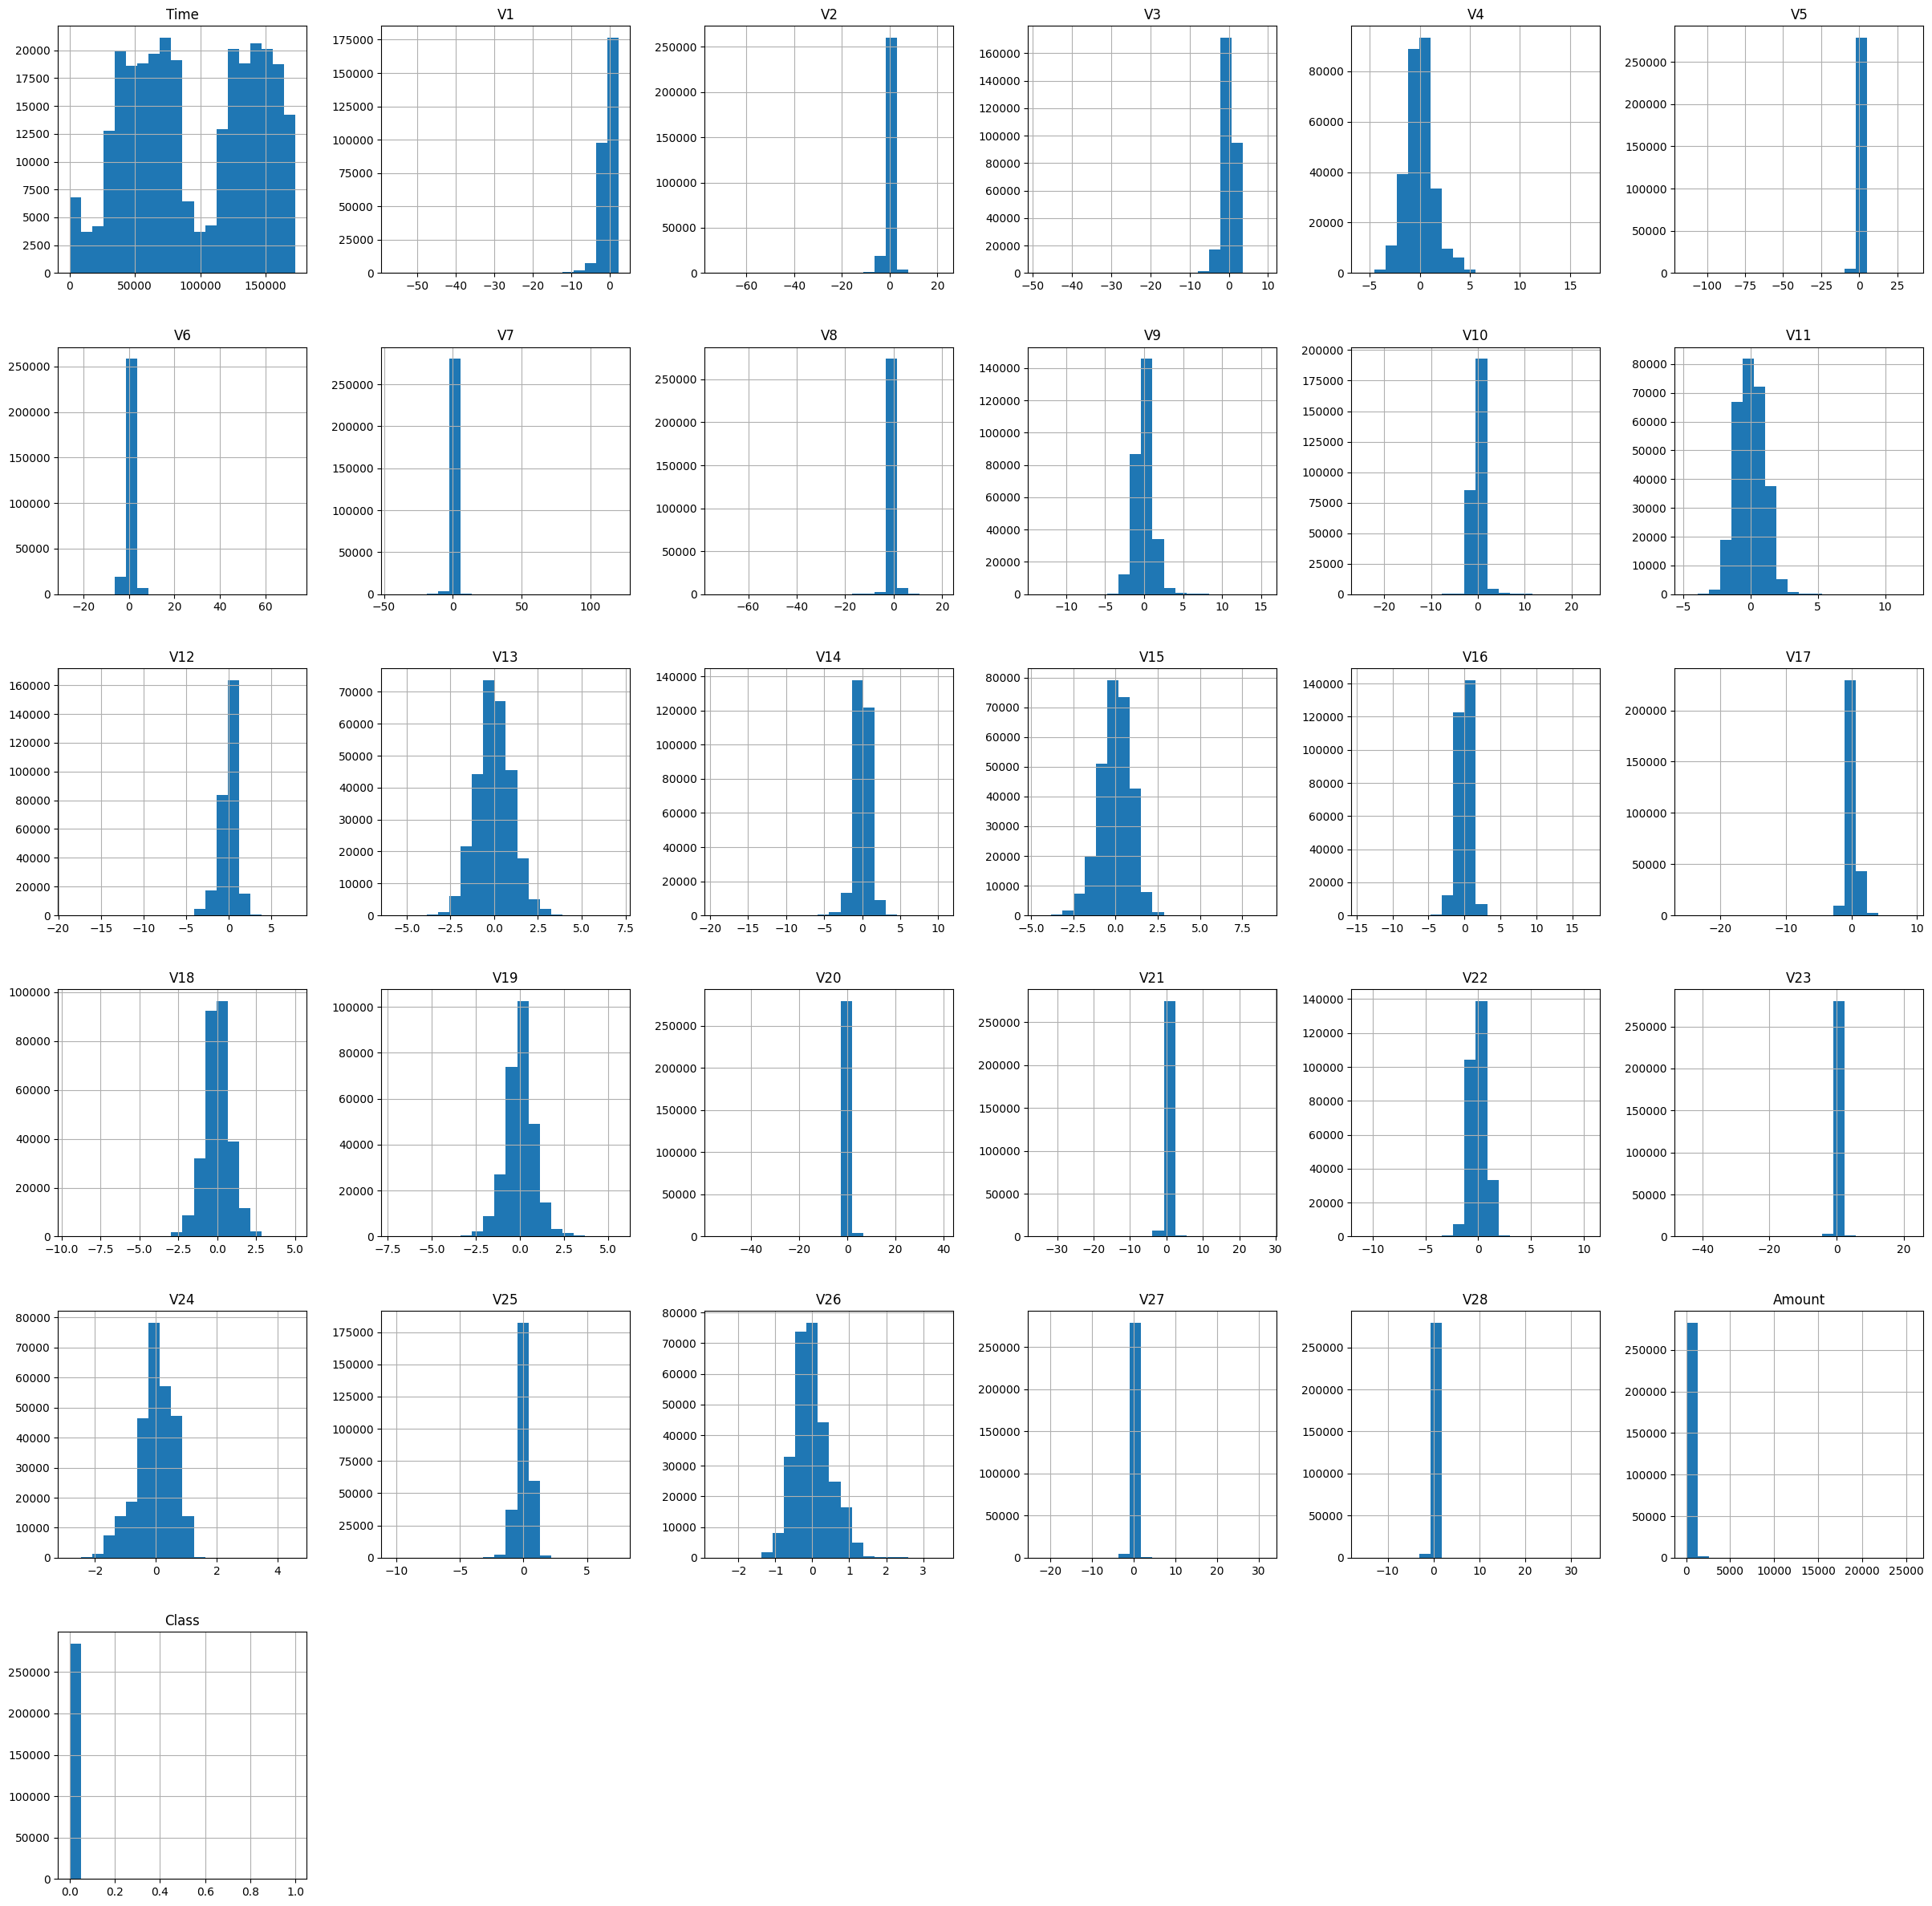

In [9]:
df.hist(bins = 20, figsize = (30,30))

## Stratified Splitting

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X = df.drop(columns = 'Class')
Y = df['Class']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,random_state = 42, test_size = 0.2, stratify = Y)

In [12]:
type(Y)

pandas.Series

In [13]:
y_train = ((Y_train == 1).sum() / Y_train.count()) * 100
y_train

np.float64(0.17292457591783889)

In [14]:
y_test = ((Y_test == 1).sum() / Y_test.count())* 100
y_test

np.float64(0.17204452090867595)

In [15]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [16]:
pipeline1 = Pipeline(steps = [('scaler',StandardScaler()),('smote',SMOTE(sampling_strategy = 'minority', random_state = 42)),('model',LogisticRegression())])

In [17]:
pipeline2 = Pipeline(steps = [('smote',SMOTE(sampling_strategy = 'minority', random_state = 42)),('model',RandomForestClassifier(n_estimators = 30,random_state = 42))])

In [18]:
from sklearn.model_selection import GridSearchCV

In [19]:
params_grid1 = {
    'smote__k_neighbors': [3,5,7],
    'model__C': [0.01,0.1,1.0]
}
params_grid2 = {
    'smote__k_neighbors': [3,5,7],
    'model__max_depth': [10,20,None]
}

In [20]:
print("Pipeline 1 with Logisitic Regression")
clf1 = GridSearchCV(pipeline1, params_grid1, cv = 5,n_jobs = -1, scoring = 'roc_auc')

Pipeline 1 with Logisitic Regression


In [21]:
print("Pipeline 2 with Random Forest Classifier")
clf2 = GridSearchCV(pipeline2, params_grid2, cv = 5,n_jobs = -1, scoring = 'roc_auc')

Pipeline 2 with Random Forest Classifier


In [22]:
clf1.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'smote__k_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [23]:
clf1_df = pd.DataFrame(clf1.cv_results_)
clf1_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_smote__k_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,10.428224,0.526399,0.132358,0.013593,0.01,3,"{'model__C': 0.01, 'smote__k_neighbors': 3}",0.959788,0.982665,0.985207,0.981282,0.992890,0.980366,0.011044,1
1,10.253394,0.632471,0.155357,0.025949,0.01,5,"{'model__C': 0.01, 'smote__k_neighbors': 5}",0.961353,0.982490,0.981283,0.980646,0.993099,0.979774,0.010269,3
2,8.837691,1.530770,0.131708,0.011128,0.01,7,"{'model__C': 0.01, 'smote__k_neighbors': 7}",0.961624,0.982280,0.981586,0.980906,0.993417,0.979963,0.010259,2
3,8.565499,0.657583,0.141733,0.020503,0.10,3,"{'model__C': 0.1, 'smote__k_neighbors': 3}",0.956523,0.982161,0.983833,0.981651,0.993106,0.979455,0.012195,4
4,8.485619,0.561757,0.131426,0.020989,0.10,5,"{'model__C': 0.1, 'smote__k_neighbors': 5}",0.957379,0.981907,0.980071,0.981088,0.993328,0.978755,0.011717,8
5,8.032412,0.317964,0.146712,0.025999,0.10,7,"{'model__C': 0.1, 'smote__k_neighbors': 7}",0.957841,0.981848,0.980429,0.981142,0.993638,0.978980,0.011634,6
6,8.811766,0.673013,0.212603,0.146137,1.00,3,"{'model__C': 1.0, 'smote__k_neighbors': 3}",0.956158,0.982119,0.983408,0.981628,0.993122,0.979287,0.012303,5
7,8.378590,0.730107,0.095883,0.024460,1.00,5,"{'model__C': 1.0, 'smote__k_neighbors': 5}",0.956920,0.981907,0.979813,0.981189,0.993392,0.978644,0.011899,9
8,7.173974,0.372292,0.066147,0.023337,1.00,7,"{'model__C': 1.0, 'smote__k_neighbors': 7}",0.957498,0.981800,0.980013,0.981133,0.993692,0.978827,0.011760,7


In [24]:
clf2.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'smote__k_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [25]:
clf2_df = pd.DataFrame(clf2.cv_results_)
clf2_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_smote__k_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,133.334809,2.543733,0.316409,0.151308,10,3,"{'model__max_depth': 10, 'smote__k_neighbors': 3}",0.968778,0.986614,0.990018,0.982645,0.992190,0.984049,0.008290,1
1,135.117302,2.423405,0.283870,0.054859,10,5,"{'model__max_depth': 10, 'smote__k_neighbors': 5}",0.958340,0.982999,0.988463,0.971376,0.992323,0.978700,0.012390,3
2,135.493750,2.337537,0.247429,0.058444,10,7,"{'model__max_depth': 10, 'smote__k_neighbors': 7}",0.971657,0.981716,0.986707,0.966439,0.990711,0.979446,0.009106,2
3,199.313707,5.078399,0.309200,0.112442,20,3,"{'model__max_depth': 20, 'smote__k_neighbors': 3}",0.932434,0.971165,0.962212,0.967662,0.952424,0.957179,0.013898,9
4,199.760408,3.682298,0.323903,0.064828,20,5,"{'model__max_depth': 20, 'smote__k_neighbors': 5}",0.944502,0.970947,0.975415,0.966742,0.969897,0.965500,0.010861,5
5,204.649178,7.345864,0.306053,0.105312,20,7,"{'model__max_depth': 20, 'smote__k_neighbors': 7}",0.947270,0.979500,0.964699,0.961779,0.985609,0.967772,0.013575,4
6,211.630160,11.420143,0.234648,0.010190,None,3,"{'model__max_depth': None, 'smote__k_neighbors...",0.926422,0.972220,0.965795,0.959498,0.985366,0.961860,0.019682,6
7,192.327313,15.029126,0.226334,0.058586,None,5,"{'model__max_depth': None, 'smote__k_neighbors...",0.931915,0.972158,0.958781,0.965234,0.965375,0.958693,0.014041,8
8,165.004467,3.861292,0.152162,0.010747,None,7,"{'model__max_depth': None, 'smote__k_neighbors...",0.944629,0.978100,0.958810,0.958675,0.965987,0.961240,0.010911,7


In [26]:
clf2.best_score_

np.float64(0.9840490838283245)

In [27]:
clf2.best_params_

{'model__max_depth': 10, 'smote__k_neighbors': 3}

In [29]:
df.shape

(284807, 31)

In [30]:
clf2.best_estimator_

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'minority'
,random_state,42
,k_neighbors,3
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


# Model Evaluation

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
def evaluate_model(grid_model,model_name):
    print(f"Best parameters: {grid_model.best_params_}")
    best_predictor = grid_model.best_estimator_
    predictions = best_predictor.predict(X_test)
    best_prob = best_predictor.predict_proba(X_test)[:,1]
    print("Classification Report:")
    print(classification_report(Y_test, predictions))
    print("Confusion matrix:")
    print(confusion_matrix(Y_test,predictions))
    print("ROC_AUC Score:")
    print(roc_auc_score(Y_test,predictions))
evaluate_model(clf1,"Logistic Regression")
evaluate_model(clf2,"Random Forest Classifier")

Best parameters: {'model__C': 0.01, 'smote__k_neighbors': 3}
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Confusion matrix:
[[55431  1433]
 [    8    90]]
ROC_AUC Score:
0.9465834343022521
Best parameters: {'model__max_depth': 10, 'smote__k_neighbors': 3}
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.50      0.87      0.64        98

    accuracy                           1.00     56962
   macro avg       0.75      0.93      0.82     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix:
[[56780    84]
 [   13    85]]
ROC_AUC Score:
0.9329348649983348
